# Caso de Estudio - Olist.
Sofia Herrera - Parcial 2

# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import radians, sin, cos, sqrt, asin

from scipy import stats
from scipy.stats import expon, gamma, lognorm, beta, bernoulli

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Transformación de Datos

Bases de Datos

In [2]:
ordenes = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
items_orden = pd.read_csv("olist_order_items_dataset.csv")
clientes = pd.read_csv("olist_customers_dataset.csv")
vendedores = pd.read_csv("olist_sellers_dataset.csv")
geolocalizacion = pd.read_csv("olist_geolocation_dataset.csv")

Dimensiones de las bases de datos

In [3]:
print("Dimensiones de los archivos seleccionados:\n")
print("Órdenes:", ordenes.shape)
print("Reseñas:", reviews.shape)
print("Ítems de la orden:", items_orden.shape)
print("Clientes:", clientes.shape)
print("Vendedores:", vendedores.shape)
print("Geolocalización:", geolocalizacion.shape)

Dimensiones de los archivos seleccionados:

Órdenes: (99441, 8)
Reseñas: (99224, 7)
Ítems de la orden: (112650, 7)
Clientes: (99441, 5)
Vendedores: (3095, 4)
Geolocalización: (1000163, 5)


Revisión de columnas

In [4]:
print("Columnas de órdenes:\n", ordenes.columns.tolist(), "\n")
print("Columnas de reseñas:\n", reviews.columns.tolist(), "\n")
print("Columnas de ítems:\n", items_orden.columns.tolist(), "\n")
print("Columnas de clientes:\n", clientes.columns.tolist(), "\n")
print("Columnas de vendedores:\n", vendedores.columns.tolist(), "\n")
print("Columnas de geolocalización:\n", geolocalizacion.columns.tolist())

Columnas de órdenes:
 ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'] 

Columnas de reseñas:
 ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'] 

Columnas de ítems:
 ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'] 

Columnas de clientes:
 ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state'] 

Columnas de vendedores:
 ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'] 

Columnas de geolocalización:
 ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


Conversión a fechas

In [5]:
columnas_fecha_ordenes = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for columna in columnas_fecha_ordenes:
    ordenes[columna] = pd.to_datetime(ordenes[columna], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
items_orden["shipping_limit_date"] = pd.to_datetime(items_orden["shipping_limit_date"], errors="coerce")

Revisión de valores nulos

In [6]:
print("Valores nulos en órdenes:\n")
print(ordenes.isnull().sum(), "\n")

print("Valores nulos en reseñas:\n")
print(reviews.isnull().sum(), "\n")

print("Valores nulos en ítems de la orden:\n")
print(items_orden.isnull().sum(), "\n")

print("Valores nulos en clientes:\n")
print(clientes.isnull().sum(), "\n")

print("Valores nulos en vendedores:\n")
print(vendedores.isnull().sum(), "\n")

print("Valores nulos en geolocalización:\n")
print(geolocalizacion.isnull().sum(), "\n")

Valores nulos en órdenes:

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

Valores nulos en reseñas:

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64 

Valores nulos en ítems de la orden:

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

Valores nulos en clientes:

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
custom

Consolidación de coordenadas por código postal

In [7]:
geo_promedio = (
    geolocalizacion
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean"
    })
)

geo_promedio.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


Se consolidan las coordenadas por código postal, calculando la latitud y longitud promedio, porque un mismo ZIP puede aparecer varias veces en la base de geolocalización.Esto permite tener una sola ubicación representativa por código postal.

Integración de coordenadas de clientes

In [8]:
clientes_geo = clientes.merge(
    geo_promedio,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

clientes_geo = clientes_geo.rename(columns={
    "geolocation_lat": "latitud_cliente",
    "geolocation_lng": "longitud_cliente"
})

clientes_geo = clientes_geo.drop(columns=["geolocation_zip_code_prefix"])
clientes_geo.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,latitud_cliente,longitud_cliente
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925


Integración de coordenadas de vendedores

In [9]:
vendedores_geo = vendedores.merge(
    geo_promedio,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

vendedores_geo = vendedores_geo.rename(columns={
    "geolocation_lat": "latitud_vendedor",
    "geolocation_lng": "longitud_vendedor"
})

vendedores_geo = vendedores_geo.drop(columns=["geolocation_zip_code_prefix"])
vendedores_geo.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,latitud_vendedor,longitud_vendedor
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909572,-43.177703
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657242,-46.612831
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964803,-46.534419


Se integran las coordenadas geográficas a la tabla de clientes y vendedores mediante el código postal (ZIP). Esto permite asignar una latitud y longitud a cada cliente, lo cual es necesario para calcular la distancia entre cliente y vendedor en etapas posteriores del análisis.

Agregación de ítems por orden

In [10]:
items_orden_resumido = (
    items_orden
    .groupby("order_id", as_index=False)
    .agg({
        "price": "sum",
        "freight_value": "sum",
        "seller_id": "nunique",
        "order_item_id": "count"
    })
    .rename(columns={
        "price": "precio_total_productos",
        "freight_value": "flete_total",
        "seller_id": "numero_vendedores",
        "order_item_id": "numero_items"
    })
)

items_orden_resumido

,order_id,precio_total_productos,flete_total,numero_vendedores,numero_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1
...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,1,1
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,1,1
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,1,1
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72,1,1


En esta etapa se realiza la agregación de los ítems a nivel de orden, ya que una misma orden puede contener múltiples productos. A partir de esta transformación se calculan variables clave como el precio total de los productos, el costo total de envío, el número de vendedores involucrados y la cantidad de ítems por pedido. Este proceso es fundamental porque permite unificar la información a nivel de orden, que es la unidad de análisis del proyecto, facilitando así el estudio de cómo los factores logísticos influyen en la satisfacción del cliente.

Selección del vendedor principal por orden

In [11]:
vendedor_principal_por_orden = (
    items_orden
    .sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "seller_id"]]
)

vendedor_principal_por_orden

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87
...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,b8bc237ba3788b23da09c0f1f3a3288c
112646,fffcd46ef2263f404302a634eb57f7eb,f3c38ab652836d21de61fb8314b69182
112647,fffce4705a9662cd70adb13d4a31832d,c3cfdc648177fdbbbb35635a37472c53
112648,fffe18544ffabc95dfada21779c9644f,2b3e4a2a3ea8e01938cabda2a3e5cc79


En esta etapa se selecciona un único vendedor por cada orden, debido a que un pedido puede incluir productos provenientes de múltiples vendedores. Para ello, se ordenan los ítems dentro de cada orden según su precio en orden descendente y se conserva únicamente el vendedor asociado al producto de mayor valor. Esta aproximación permite asignar un punto de origen representativo para cada pedido, lo cual es necesario para el cálculo de la distancia entre vendedor y cliente en el análisis logístico.

Construcción de la base maestra

In [12]:
base_maestra = (
    ordenes
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
    .merge(items_orden_resumido, on="order_id", how="left")
    .merge(vendedor_principal_por_orden, on="order_id", how="left")
    .merge(
        clientes_geo[["customer_id", "customer_city", "customer_state", "latitud_cliente", "longitud_cliente"]],
        on="customer_id",
        how="left"
    )
    .merge(
        vendedores_geo[["seller_id", "seller_city", "seller_state", "latitud_vendedor", "longitud_vendedor"]],
        on="seller_id",
        how="left"
    )
)

print("Dimensión de la base maestra:", base_maestra.shape)
base_maestra.head()

Dimensión de la base maestra: (99224, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,precio_total_productos,flete_total,numero_vendedores,numero_items,seller_id,customer_city,customer_state,latitud_cliente,longitud_cliente,seller_city,seller_state,latitud_vendedor,longitud_vendedor
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,29.99,8.72,1.0,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,sao paulo,SP,-23.576983,-46.587161,maua,SP,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,118.70,22.76,1.0,1.0,289cdb325fb7e7f891c38608bf9e0962,barreiras,BA,-12.177924,-44.660711,belo horizonte,SP,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,159.90,19.22,1.0,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,vianopolis,GO,-16.745150,-48.514783,guariba,SP,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,45.00,27.20,1.0,1.0,66922902710d126a0e7d26b0e3805106,sao goncalo do amarante,RN,-5.774190,-35.271143,belo horizonte,MG,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,19.90,8.72,1.0,1.0,2c9e548be18521d1c43cde1c582c6de8,santo andre,SP,-23.676370,-46.514627,mogi das cruzes,SP,-23.543395,-46.262086


Se construye la base maestra del análisis mediante la integración de los diferentes archivos seleccionados. Se combinan las órdenes con la información de reseñas, los costos asociados a los ítems, el vendedor principal, y las características geográficas tanto de clientes como de vendedores. Este proceso permite consolidar en una única tabla todas las variables relevantes a nivel de pedido, facilitando el análisis conjunto de factores logísticos, económicos y de ubicación sobre la satisfacción del cliente. La base resultante constituye el insumo principal para las etapas posteriores del análisis estadístico y modelado

Filtrado de pedidos entregados

In [13]:
base_maestra = base_maestra[base_maestra["order_status"] == "delivered"].copy()

print("Dimensión luego de filtrar pedidos entregados:", base_maestra.shape)

Dimensión luego de filtrar pedidos entregados: (96361, 22)


Eliminación de registros con datos críticos faltantes

In [14]:
base_maestra = base_maestra.dropna(subset=[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_score",
    "flete_total",
    "precio_total_productos",
    "latitud_cliente",
    "longitud_cliente",
    "latitud_vendedor",
    "longitud_vendedor"
])

print("Dimensión luego de eliminar nulos críticos:", base_maestra.shape)

Dimensión luego de eliminar nulos críticos: (95872, 22)


Creación de variables derivadas logísticas y de satisfacción

In [15]:
base_maestra["tiempo_entrega_dias"] = (
    (base_maestra["order_delivered_customer_date"] - base_maestra["order_purchase_timestamp"])
    .dt.total_seconds() / (60 * 60 * 24)
)

base_maestra["retraso_dias"] = (
    (base_maestra["order_delivered_customer_date"] - base_maestra["order_estimated_delivery_date"])
    .dt.total_seconds() / (60 * 60 * 24)
)

base_maestra["retraso_dias"] = base_maestra["retraso_dias"].clip(lower=0)

base_maestra["proporcion_flete"] = (
    base_maestra["flete_total"] / (base_maestra["precio_total_productos"] + base_maestra["flete_total"])
)

base_maestra["pedido_tardio"] = (
    base_maestra["order_delivered_customer_date"] > base_maestra["order_estimated_delivery_date"]
).astype(int)

base_maestra["resena_negativa"] = (base_maestra["review_score"] <= 2).astype(int)
base_maestra["resena_positiva"] = (base_maestra["review_score"] >= 4).astype(int)

base_maestra[[
    "tiempo_entrega_dias",
    "retraso_dias",
    "flete_total",
    "proporcion_flete",
    "review_score",
    "pedido_tardio"
]].head(35)

,tiempo_entrega_dias,retraso_dias,flete_total,proporcion_flete,review_score,pedido_tardio
0,8.436574,0.000000,8.72,0.225265,4,0
1,13.782037,0.000000,22.76,0.160894,4,0
2,9.394213,0.000000,19.22,0.107302,5,0
3,13.208750,0.000000,27.20,0.376731,5,0
4,2.873877,0.000000,8.72,0.304682,5,0
5,16.542245,0.000000,27.36,0.156111,4,0
7,9.989826,0.000000,15.17,0.201836,5,0
8,9.818762,0.000000,16.05,0.446453,1,0
9,18.221852,0.000000,19.77,0.116459,5,0
10,12.650937,0.000000,61.06,0.235698,1,0


Cálculo de distancia geográfica con Haversine

In [16]:
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    radio_tierra_km = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    diferencia_lat = lat2 - lat1
    diferencia_lon = lon2 - lon1

    a = np.sin(diferencia_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(diferencia_lon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return radio_tierra_km * c

base_maestra["distancia_km"] = calcular_distancia_haversine(
    base_maestra["latitud_vendedor"],
    base_maestra["longitud_vendedor"],
    base_maestra["latitud_cliente"],
    base_maestra["longitud_cliente"]
)

base_maestra["distancia_km"].describe()

,distancia_km
count,95872.000000
mean,600.312198
std,592.940696
min,0.000000
25%,186.715398
50%,433.882900
75%,798.302032
max,8677.911622


Limpieza final de valores extremos o inválidos

In [17]:
base_maestra = base_maestra.replace([np.inf, -np.inf], np.nan)

base_maestra = base_maestra.dropna(subset=[
    "tiempo_entrega_dias",
    "retraso_dias",
    "distancia_km",
    "flete_total",
    "proporcion_flete",
    "review_score"
])

base_maestra = base_maestra[
    (base_maestra["tiempo_entrega_dias"] > 0) &
    (base_maestra["tiempo_entrega_dias"] < 100) &
    (base_maestra["distancia_km"] >= 0) &
    (base_maestra["distancia_km"] < 5000) &
    (base_maestra["proporcion_flete"] >= 0) &
    (base_maestra["proporcion_flete"] < 1)
]

print("Dimensión final de la base analítica:", base_maestra.shape)

Dimensión final de la base analítica: (95808, 29)


In [18]:
base_maestra["nivel_satisfaccion"] = base_maestra["review_score"].apply(
    lambda x: "alta" if x >= 4 else "baja"
)

base_maestra["nivel_satisfaccion"].value_counts()

,count
nivel_satisfaccion,
alta,75634
baja,20174


Estadísticas descriptivas de las variables principales

In [19]:
base_maestra[[
    "tiempo_entrega_dias",
    "retraso_dias",
    "distancia_km",
    "flete_total",
    "proporcion_flete",
    "review_score"
]].describe()

,tiempo_entrega_dias,retraso_dias,distancia_km,flete_total,proporcion_flete,review_score
count,95808.000000,95808.000000,95808.000000,95808.000000,95808.000000,95808.000000
mean,12.429336,0.680586,599.844419,22.746622,0.209070,4.156354
std,8.818845,3.560337,591.689215,21.518930,0.125587,1.284362
min,0.533414,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.750359,0.000000,186.612530,13.820000,0.116701,4.000000
50%,10.200382,0.000000,433.812614,17.160000,0.183301,5.000000
75%,15.630712,0.000000,797.719998,23.980000,0.275780,5.000000
max,99.947488,83.578206,4791.614270,1794.960000,0.955451,5.000000


Se observa que el tiempo promedio de entrega es de aproximadamente 12.4 días, mientras que el retraso promedio es relativamente bajo, cercano a 0.68 días, lo que indica que la mayoría de los pedidos se entregan dentro del tiempo estimado. La distancia promedio entre cliente y vendedor es de aproximadamente 600 km, lo que refleja una alta dispersión geográfica. Asimismo, el costo de flete representa en promedio cerca del 21% del valor total del pedido. En términos de satisfacción, la calificación promedio es de 4.15, lo que sugiere una percepción positiva general por parte de los clientes. Sin embargo, se identifican valores extremos en variables como distancia, retraso y costo de envío, lo que evidencia la existencia de casos atípicos que pueden influir en el análisis.

Matriz de correlación

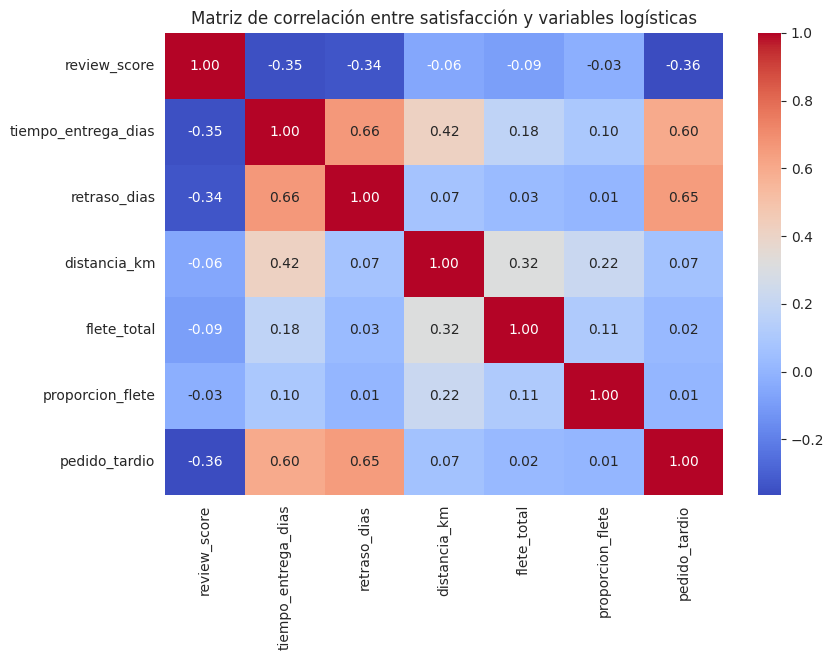

In [20]:
matriz_correlacion = base_maestra[[
    "review_score",
    "tiempo_entrega_dias",
    "retraso_dias",
    "distancia_km",
    "flete_total",
    "proporcion_flete",
    "pedido_tardio"
]].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre satisfacción y variables logísticas")
plt.show()

La matriz de correlación permite analizar la relación entre las variables logísticas y la satisfacción del cliente. Se observa que el tiempo de entrega (-0.35), el retraso (-0.34) y el indicador de pedido tardío (-0.36) presentan correlaciones negativas moderadas con la calificación, lo que indica que a medida que aumentan estos factores, la satisfacción del cliente disminuye. En contraste, variables como la distancia (-0.06), el costo total de envío (-0.09) y la proporción del flete (-0.03) muestran relaciones débiles o prácticamente nulas con la satisfacción. Esto sugiere que el cumplimiento en los tiempos de entrega es el principal determinante de la experiencia del cliente, por encima de factores económicos o geográficos.

In [21]:
comparacion_base_tardanza = (
    base_maestra
    .groupby("nivel_satisfaccion")
    .agg({
        "tiempo_entrega_dias": "mean",
        "retraso_dias": "mean",
        "distancia_km": "mean",
        "flete_total": "mean",
        "proporcion_flete": "mean",
        "pedido_tardio": "mean",
        "review_score": "mean"
    })
    .round(3)
)

comparacion_base_tardanza


,tiempo_entrega_dias,retraso_dias,distancia_km,flete_total,proporcion_flete,pedido_tardio,review_score
nivel_satisfaccion,,,,,,,
alta,11.032,0.146,584.956,21.858,0.207,0.035,4.75
baja,17.670,2.683,655.662,26.077,0.216,0.247,1.93


A partir del análisis de promedios por nivel de satisfacción, se identifican diferencias relevantes entre los pedidos con alta y baja satisfacción del cliente. En particular, los pedidos con baja satisfacción presentan un mayor tiempo promedio de entrega (17.5 días frente a 10.9 días), así como un mayor retraso (2.7 días frente a 0.15 días). De igual forma, la proporción de pedidos tardíos es considerablemente superior en el grupo de baja satisfacción (24.8%) en comparación con el grupo de alta satisfacción (3.5%), lo que sugiere una fuerte relación entre el incumplimiento en los tiempos de entrega y la percepción del cliente.

Por otro lado, variables como la distancia y el costo del flete también presentan incrementos en el grupo de baja satisfacción, aunque en menor magnitud, lo que indica que su impacto podría ser secundario o indirecto.

En conjunto, estos resultados preliminares sugieren que los factores asociados al tiempo, especialmente el retraso y la tardanza en la entrega, podrían ser determinantes en la satisfacción del cliente

Boxplots según nivel de satisfacción alta vs baja sin datos atípicos

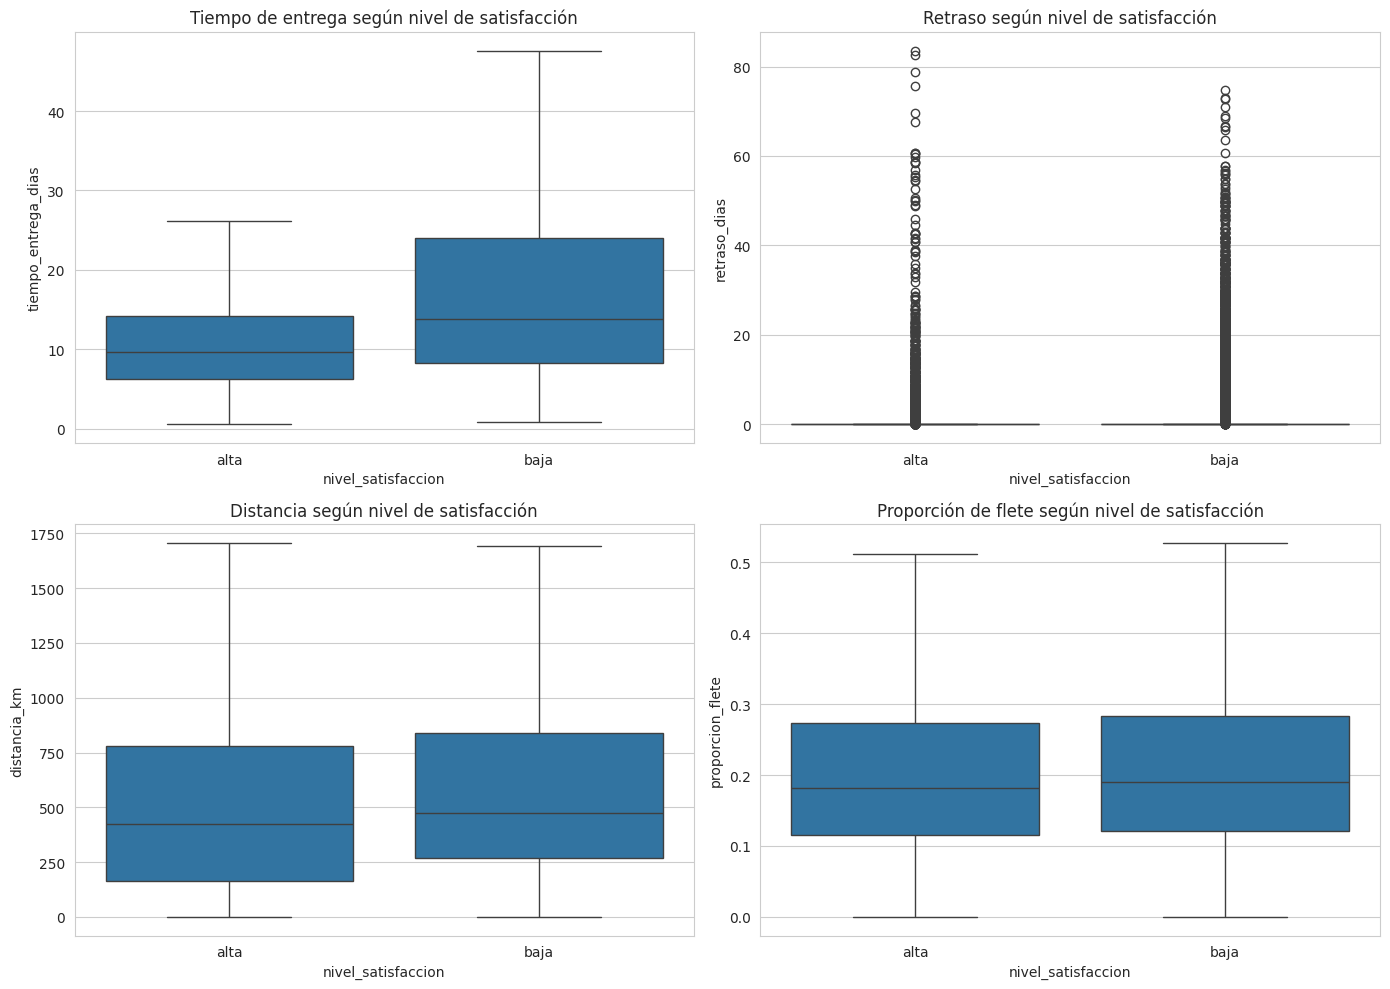

In [22]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=base_maestra, x="nivel_satisfaccion", y="tiempo_entrega_dias", ax=ejes[0, 0],showfliers=False)
ejes[0, 0].set_title("Tiempo de entrega según nivel de satisfacción")

sns.boxplot(data=base_maestra, x="nivel_satisfaccion", y="retraso_dias", ax=ejes[0, 1])
ejes[0, 1].set_title("Retraso según nivel de satisfacción")

sns.boxplot(data=base_maestra, x="nivel_satisfaccion", y="distancia_km", ax=ejes[1, 0], showfliers=False)
ejes[1, 0].set_title("Distancia según nivel de satisfacción")

sns.boxplot(data=base_maestra, x="nivel_satisfaccion", y="proporcion_flete", ax=ejes[1, 1], showfliers=False)
ejes[1, 1].set_title("Proporción de flete según nivel de satisfacción")

plt.tight_layout()
plt.show()


Se evidencia que los pedidos con baja satisfacción se caracterizan principalmente por mayores tiempos de entrega y una mayor presencia de retrasos extremos. Aunque la distancia presenta una ligera variación entre los grupos, su impacto es menor y probablemente indirecto. Por otro lado, el costo del envío no muestra diferencias relevantes, lo que sugiere que la experiencia del cliente está mucho más influenciada por el cumplimiento en los tiempos que por factores económicos.

Comparación directa de pedidos tardíos por nivel de satisfacción

In [23]:
comparacion_tardanza = (
    base_maestra
    .groupby("nivel_satisfaccion")["pedido_tardio"]
    .mean()
    .reset_index()
    .rename(columns={"pedido_tardio": "proporcion_pedidos_tardios"})
)

comparacion_tardanza

,nivel_satisfaccion,proporcion_pedidos_tardios
0,alta,0.034574
1,baja,0.246505


Gráfico de proporción de pedidos tardíos

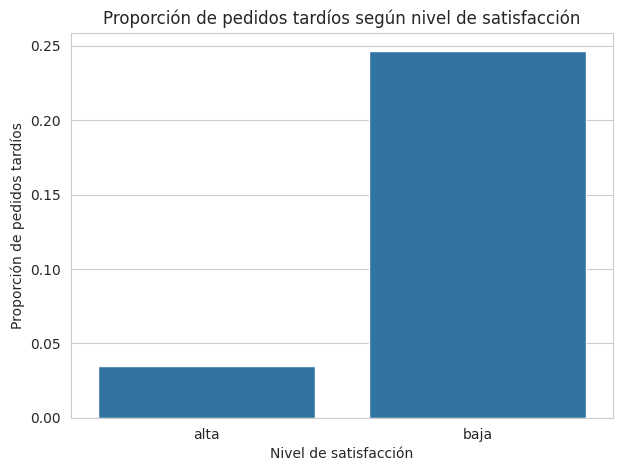

In [24]:
plt.figure(figsize=(7, 5))
sns.barplot(data=comparacion_tardanza, x="nivel_satisfaccion", y="proporcion_pedidos_tardios")
plt.title("Proporción de pedidos tardíos según nivel de satisfacción")
plt.ylabel("Proporción de pedidos tardíos")
plt.xlabel("Nivel de satisfacción")
plt.show()

El análisis de la proporción de pedidos tardíos evidencia una diferencia significativa entre los niveles de satisfacción. Mientras que solo el 3.5% de los pedidos con alta satisfacción presentan retraso, esta proporción aumenta a aproximadamente 24.7% en los pedidos con baja satisfacción. Esto indica que los pedidos tardíos son considerablemente más frecuentes en los casos de insatisfacción, sugiriendo que el incumplimiento en los tiempos de entrega es uno de los principales factores que afectan negativamente la experiencia del cliente.

#  Aplicación de estimación por máxima verosimilitud con comparación de modelos mediante AIC/BIC

Selección de variable para MLE

In [25]:
datos_tiempo = base_maestra["tiempo_entrega_dias"].dropna()

# evitar ceros para log-normal
datos_tiempo = datos_tiempo[datos_tiempo > 0]

Ajuste Normal

In [26]:
mu_normal, sigma_normal = stats.norm.fit(datos_tiempo)

log_likelihood_normal = np.sum(
    stats.norm.logpdf(datos_tiempo, mu_normal, sigma_normal)
)

k_normal = 2  # parámetros: media y desviación

aic_normal = 2 * k_normal - 2 * log_likelihood_normal
bic_normal = k_normal * np.log(len(datos_tiempo)) - 2 * log_likelihood_normal

Ajuste Log-Normal

In [27]:
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(datos_tiempo, floc=0)

log_likelihood_lognorm = np.sum(
    stats.lognorm.logpdf(datos_tiempo, shape_lognorm, loc_lognorm, scale_lognorm)
)

k_lognorm = 2  # shape y scale (loc fijo)

aic_lognorm = 2 * k_lognorm - 2 * log_likelihood_lognorm
bic_lognorm = k_lognorm * np.log(len(datos_tiempo)) - 2 * log_likelihood_lognorm

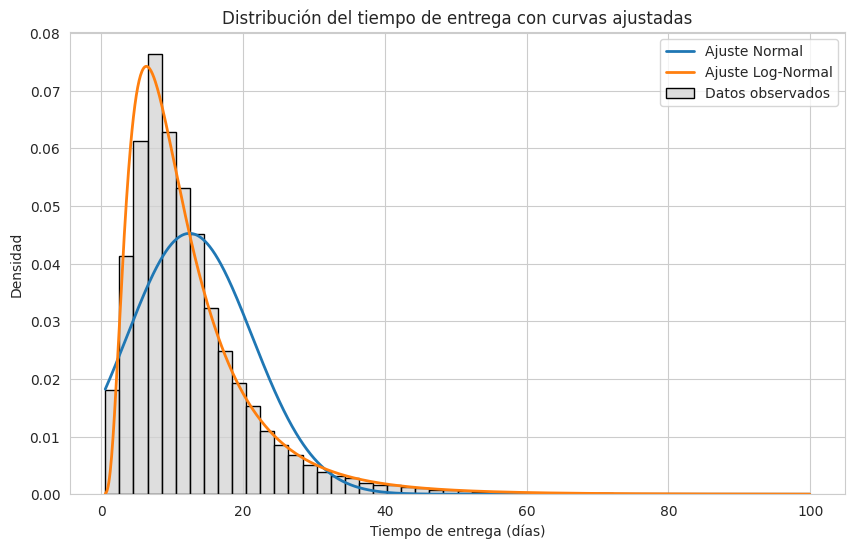

In [28]:
x_grafica = np.linspace(datos_tiempo.min(), datos_tiempo.max(), 1000)

densidad_normal = stats.norm.pdf(x_grafica, mu_normal, sigma_normal)
densidad_lognormal = stats.lognorm.pdf(x_grafica, shape_lognorm, loc_lognorm, scale_lognorm)

plt.figure(figsize=(10, 6))
sns.histplot(datos_tiempo, bins=50, stat="density", color="lightgray", edgecolor="black", label="Datos observados")
plt.plot(x_grafica, densidad_normal, linewidth=2, label="Ajuste Normal")
plt.plot(x_grafica, densidad_lognormal, linewidth=2, label="Ajuste Log-Normal")
plt.title("Distribución del tiempo de entrega con curvas ajustadas")
plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

El histograma del tiempo de entrega, junto con las curvas ajustadas, permite observar que la distribución empírica presenta asimetría positiva y una cola derecha marcada. Visualmente, la distribución Log-Normal reproduce mejor este comportamiento que la Normal

In [29]:
print("=== MODELO NORMAL ===")
print("mu:", mu_normal)
print("sigma:", sigma_normal)
print("AIC:", aic_normal)
print("BIC:", bic_normal)

print("\n=== MODELO LOG-NORMAL ===")
print("shape:", shape_lognorm)
print("scale:", scale_lognorm)
print("AIC:", aic_lognorm)
print("BIC:", bic_lognorm)

=== MODELO NORMAL ===
mu: 12.429335514682915
sigma: 8.818798559252379
AIC: 689021.4453415751
BIC: 689040.3855445107

=== MODELO LOG-NORMAL ===
shape: 0.6757215351531235
scale: 9.99651359003483
AIC: 637932.1225499156
BIC: 637951.0627528512


Se analizó la distribución del tiempo de entrega de aproximadamente 95.808 pedidos en la plataforma Olist. Para ello, se comparó el ajuste de una distribución Normal frente a una Log-Normal mediante estimación por máxima verosimilitud y los criterios de información AIC y BIC.

Los resultados muestran que la distribución Log-Normal ajusta considerablemente mejor que la Normal, con una diferencia de aproximadamente 51.089 puntos en AIC y 51.089 puntos en BIC, lo que evidencia una mejora sustancial en el ajuste del modelo.

En el caso de la distribución Normal, el parámetro estimado μ = 12.43 días indica el tiempo promedio de entrega, con una desviación estándar de σ = 8.82 días, lo que sugiere una alta variabilidad en los tiempos logísticos. Sin embargo, este modelo asume simetría, lo cual no es consistente con la naturaleza de los datos.

Por su parte, la distribución Log-Normal presenta un parámetro de forma shape = 0.68 y una escala de aproximadamente 10 días, lo que indica que la mayoría de los pedidos se concentran en tiempos de entrega relativamente bajos, pero existe una cola derecha significativa. Esto implica que una proporción de pedidos experimenta tiempos de entrega considerablemente mayores, asociados a eventos extremos dentro del proceso logístico.

En conjunto, estos resultados confirman que el tiempo de entrega presenta un comportamiento asimétrico y con presencia de valores extremos, lo cual es consistente con los hallazgos previos sobre retrasos y permite explicar por qué estos eventos tienen un impacto relevante en la satisfacción del cliente.

# inferencia bayesiana con especificación explícita del prior y el posterior

Para modelar la probabilidad de que un pedido sea tardío, se definió el parámetro $\theta$ como la probabilidad de tardanza dentro de cada nivel de satisfacción. Antes de observar los datos, se asumió un prior no informativo:

$$
\theta \sim \text{Beta}(1,1)
$$

Dado que cada pedido puede clasificarse como tardío o no tardío, la evidencia observada se modeló con una verosimilitud Binomial:

$$
X \mid \theta \sim \text{Binomial}(n,\theta)
$$

donde $n$ representa el número total de pedidos del grupo y $X$ la cantidad de pedidos tardíos observados.

Aplicando el teorema de Bayes:

$$
P(\theta \mid X) \propto P(X \mid \theta)\, P(\theta)
$$

y aprovechando la conjugación Beta-Binomial, la distribución posterior toma la forma:

$$
\theta \mid X \sim \text{Beta}(\alpha + X,\; \beta + n - X)
$$

Contar éxitos y fracasos

In [30]:
datos_bayes = (
    base_maestra
    .groupby("nivel_satisfaccion")["pedido_tardio"]
    .agg(total_pedidos="count", pedidos_tardios="sum")
    .reset_index()
)

datos_bayes["pedidos_no_tardios"] = (
    datos_bayes["total_pedidos"] - datos_bayes["pedidos_tardios"]
)

datos_bayes

,nivel_satisfaccion,total_pedidos,pedidos_tardios,pedidos_no_tardios
0,alta,75634,2615,73019
1,baja,20174,4973,15201


In [31]:
alpha_prior = 1
beta_prior = 1

print("Prior especificado: Beta(", alpha_prior, ",", beta_prior, ")", sep="")
media_prior = alpha_prior / (alpha_prior + beta_prior)
print("Media del prior:", media_prior)
resultados_bayes = []

for _, fila in datos_bayes.iterrows():
    n = fila["total_pedidos"]
    x = fila["pedidos_tardios"]

    alpha_posterior = alpha_prior + x
    beta_posterior = beta_prior + (n - x)

    media_posterior = alpha_posterior / (alpha_posterior + beta_posterior)

    resultados_bayes.append({
        "nivel_satisfaccion": fila["nivel_satisfaccion"],
        "alpha_prior": alpha_prior,
        "beta_prior": beta_prior,
        "n": n,
        "x": x,
        "alpha_posterior": alpha_posterior,
        "beta_posterior": beta_posterior,
        "media_posterior": media_posterior
    })

print("Media del posterior:", media_posterior)
resultados_bayes = pd.DataFrame(resultados_bayes)
resultados_bayes

Prior especificado: Beta(1,1)
Media del prior: 0.5
Media del posterior: 0.24653053132434577


,nivel_satisfaccion,alpha_prior,beta_prior,n,x,alpha_posterior,beta_posterior,media_posterior
0,alta,1,1,75634,2615,2616,73020,0.034587
1,baja,1,1,20174,4973,4974,15202,0.246531


In [32]:
comparacion_bayes_mle = pd.DataFrame({
    "nivel_satisfaccion": resultados_bayes["nivel_satisfaccion"],
    "mle_puro": resultados_bayes["x"] / resultados_bayes["n"],
    "media_posterior": resultados_bayes["media_posterior"]
})
comparacion_bayes_mle

,nivel_satisfaccion,mle_puro,media_posterior
0,alta,0.034574,0.034587
1,baja,0.246505,0.246531


Se comparó la estimación obtenida mediante máxima verosimilitud (MLE), definida como k/n, con la media de la distribución posterior bayesiana. Los resultados muestran que ambas estimaciones son prácticamente iguales, lo cual se debe al gran tamaño de la muestra, donde la información contenida en los datos domina completamente sobre el prior.

In [33]:
from scipy.stats import beta
fila_alta = resultados_bayes[resultados_bayes["nivel_satisfaccion"] == "alta"].iloc[0]
fila_baja = resultados_bayes[resultados_bayes["nivel_satisfaccion"] == "baja"].iloc[0]

alpha_alta = fila_alta["alpha_posterior"]
beta_alta = fila_alta["beta_posterior"]

alpha_baja = fila_baja["alpha_posterior"]
beta_baja = fila_baja["beta_posterior"]

print("Posterior alta satisfacción:", alpha_alta, beta_alta)
print("Posterior baja satisfacción:", alpha_baja, beta_baja)

ic_alta = beta.interval(0.95, alpha_alta, beta_alta)
ic_baja = beta.interval(0.95, alpha_baja, beta_baja)

print("Intervalo de credibilidad 95% - Alta satisfacción:", ic_alta)
print("Intervalo de credibilidad 95% - Baja satisfacción:", ic_baja)

Posterior alta satisfacción: 2616 73020
Posterior baja satisfacción: 4974 15202
Intervalo de credibilidad 95% - Alta satisfacción: (np.float64(0.033296160143071116), np.float64(0.03590056136720763))
Intervalo de credibilidad 95% - Baja satisfacción: (np.float64(0.24060756344826323), np.float64(0.25250109512963126))


A partir de las distribuciones posteriores se calcularon intervalos de credibilidad del 95% para la probabilidad de tardanza en cada nivel de satisfacción. Para los pedidos con alta satisfacción, la probabilidad de tardanza se encuentra entre 3.33% y 3.59%, mientras que para los pedidos con baja satisfacción se ubica entre 24.06% y 25.25%.

La ausencia total de traslape entre ambos intervalos confirma que la diferencia es estadísticamente significativa y robusta. Además, la estrechez de los intervalos refleja una alta certeza en la estimación, atribuida al gran tamaño de la muestra. En consecuencia, la tardanza se consolida como un factor logístico determinante en la diferenciación entre pedidos con alta y baja satisfacción.

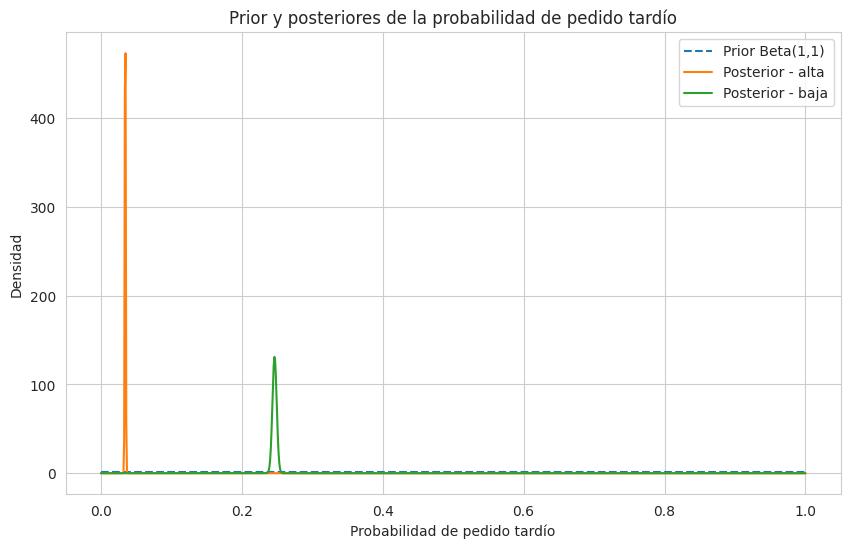

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

x = np.linspace(0, 1, 1000)

densidad_prior = beta.pdf(x, alpha_prior, beta_prior)

plt.figure(figsize=(10, 6))
plt.plot(x, densidad_prior, linestyle="--", label="Prior Beta(1,1)")

for _, fila in resultados_bayes.iterrows():
    densidad_posterior = beta.pdf(
        x,
        fila["alpha_posterior"],
        fila["beta_posterior"]
    )

    plt.plot(
        x,
        densidad_posterior,
        label=f"Posterior - {fila['nivel_satisfaccion']}"
    )

plt.title("Prior y posteriores de la probabilidad de pedido tardío")
plt.xlabel("Probabilidad de pedido tardío")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Se modeló la probabilidad de que un pedido sea tardío condicionada al nivel de satisfacción del cliente mediante inferencia bayesiana, usando un esquema Beta-Binomial. Se partió de un prior no informativo Beta(1,1), que representa una creencia inicial uniforme sobre la probabilidad de tardanza, y luego se actualizó con la evidencia observada de pedidos tardíos y no tardíos en cada grupo. Esta estrategia es coherente con la lógica bayesiana de actualizar el conocimiento previo con nueva evidencia .

El gráfico muestra que las distribuciones posteriores de la probabilidad de pedido tardío son claramente distintas entre los dos niveles de satisfacción. En el grupo de alta satisfacción, la posterior se concentra alrededor de 0.035, mientras que en el grupo de baja satisfacción se concentra alrededor de 0.247. En términos de negocio, esto significa que la probabilidad de que un pedido llegue tarde es mucho menor cuando el cliente termina satisfecho, y considerablemente mayor cuando el cliente queda insatisfecho.

La separación entre ambas distribuciones es muy marcada y prácticamente no presenta traslape visual. Esto indica que la diferencia no es marginal ni producto del azar muestral, sino un patrón robusto en los datos. Además, la alta concentración de ambas curvas refleja que existe poca incertidumbre en la estimación, debido al gran tamaño de la muestra. Por tanto, el análisis bayesiano confirma con evidencia probabilística que la tardanza en la entrega es uno de los principales factores logísticos que diferencian los pedidos con alta y baja satisfacción.

En relación con la pregunta de negocio, este resultado permite concluir que el cumplimiento del tiempo prometido no es solo una variable operativa más, sino un punto crítico de la experiencia del cliente. Mientras que factores como distancia o costo de flete mostraban efectos más moderados en análisis previos, aquí se evidencia que la probabilidad de tardanza distingue de forma muy fuerte ambos grupos. Esto encaja además con lo exigido en el proyecto, donde se pide que la inferencia bayesiana incluya prior explícito, posterior actualizado e interpretación en lenguaje de negocio

# Clustering con métricas de validación

Selección de variables

In [35]:
variables_cluster = base_maestra[[
    "tiempo_entrega_dias",
    "retraso_dias",
    "distancia_km",
    "proporcion_flete"
]].copy()

Escalamiento

In [36]:
escalador = StandardScaler()
variables_escaladas = escalador.fit_transform(variables_cluster)

Método del codo (Elbow)

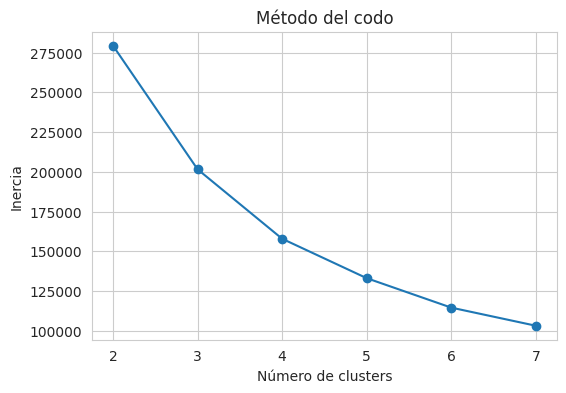

In [37]:
from sklearn.cluster import KMeans

inercia = []

rango_k = range(2, 8)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(variables_escaladas)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(6,4))
plt.plot(rango_k, inercia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

Índice de silueta, davies_bouldin y calinski_harabasz

In [156]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans

resultados_validacion = []

for k in range(2, 8):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(variables_escaladas)

    resultados_validacion.append({
        "k": k,
        "silhouette": round(silhouette_score(variables_escaladas, etiquetas), 4),
        "davies_bouldin": round(davies_bouldin_score(variables_escaladas, etiquetas), 4),
        "calinski_harabasz": round(calinski_harabasz_score(variables_escaladas, etiquetas), 2)
    })

tabla_validacion_clusters = pd.DataFrame(resultados_validacion)
tabla_validacion_clusters

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.4833,1.3441,35639.96
1,3,0.3966,1.1227,43168.08
2,4,0.3565,0.9903,45577.03
3,5,0.3307,1.0276,45015.43
4,6,0.3163,0.9955,44930.25
5,7,0.2836,0.9749,43338.45


Aunque las métricas de validación presentan comportamientos distintos, el Silhouette Score alcanza su valor máximo en k=2, indicando la mejor combinación entre cohesión interna y separación entre clusters. Si bien el índice de Davies-Bouldin continúa disminuyendo con valores mayores de k y el índice de Calinski-Harabasz alcanza su máximo en k=4, estos resultados sugieren una posible sobre-segmentación de los datos.

En este contexto, se selecciona k=2 como el número óptimo de clusters, ya que ofrece un balance adecuado entre calidad estadística e interpretabilidad, además de alinearse con la lógica del problema de negocio, donde se busca diferenciar entre pedidos eficientes y pedidos problemáticos en términos de desempeño logístico y satisfacción del cliente.

In [38]:
k_optimo = 2

modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

base_maestra["cluster"] = modelo_final.fit_predict(variables_escaladas)

Caracterización de clusters

In [39]:
perfil_clusters = (
    base_maestra
    .groupby("cluster")[[
        "tiempo_entrega_dias",
        "retraso_dias",
        "distancia_km",
        "proporcion_flete"
    ]]
    .mean()
    .round(2)
)

perfil_clusters

,tiempo_entrega_dias,retraso_dias,distancia_km,proporcion_flete
cluster,,,,
0,9.79,0.07,403.51,0.20
1,24.28,3.43,1480.53,0.27


Visualización de Clusters

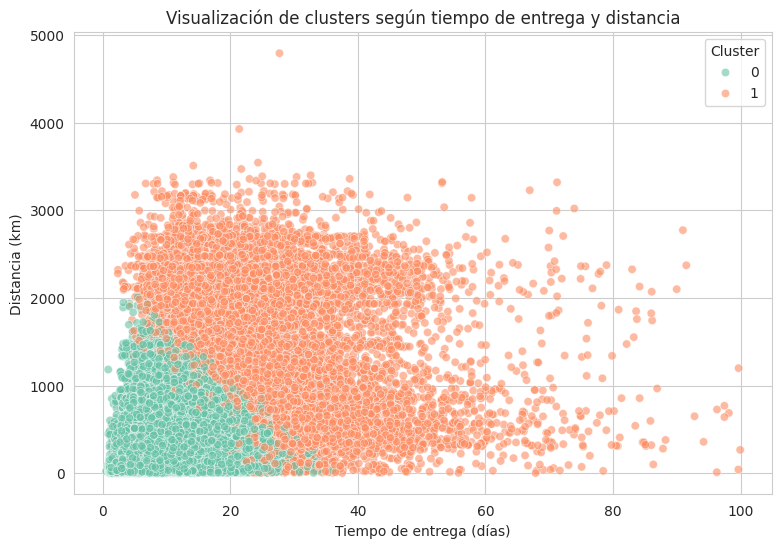

In [40]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=base_maestra,
    x="tiempo_entrega_dias",
    y="distancia_km",
    hue="cluster",
    palette="Set2",
    alpha=0.6
)
plt.title("Visualización de clusters según tiempo de entrega y distancia")
plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Distancia (km)")
plt.legend(title="Cluster")
plt.show()

Relación con satisfacción

In [41]:
satisfaccion_por_cluster = (
    base_maestra
    .groupby("cluster")["nivel_satisfaccion"]
    .value_counts(normalize=True)
    .unstack()
    .round(3)
)

satisfaccion_por_cluster

nivel_satisfaccion,alta,baja
cluster,,
0,0.827,0.173
1,0.621,0.379


El análisis de clustering permitió identificar dos grupos claramente diferenciados de pedidos. El primer cluster corresponde a pedidos con buen desempeño logístico, caracterizados por menores tiempos de entrega, ausencia de retrasos y distancias más cortas, y presenta una alta proporción de clientes satisfechos (82.7%). En contraste, el segundo cluster agrupa pedidos con mayores tiempos de entrega, retrasos más frecuentes y mayores distancias, donde la proporción de clientes insatisfechos aumenta significativamente (37.9%).

Estos resultados confirman que los factores logísticos asociados al tiempo y al cumplimiento en la entrega son determinantes en la experiencia del cliente, permitiendo distinguir entre pedidos eficientes y problemáticos.

# Monte Carlo

Dado que el análisis previo identificó la tardanza como uno de los principales factores logísticos que diferencian los pedidos con alta y baja satisfacción, se utiliza simulación Monte Carlo para proyectar su impacto en escenarios futuros. En lugar de limitarse a una probabilidad puntual de tardanza, esta técnica permite incorporar la incertidumbre estimada mediante inferencia bayesiana y traducirla en resultados operativos concretos, como el número esperado de pedidos tardíos en lotes futuros. De esta forma, Monte Carlo complementa la pregunta general del proyecto al cuantificar el efecto esperado de la tardanza bajo distintos perfiles de satisfacción del cliente.

Cuál es el impacto esperado de la tardanza en escenarios futuros bajo distintos perfiles de satisfacción?

In [42]:
# Fijar semilla para reproducibilidad
np.random.seed(42)

numero_simulaciones = 10000
pedidos_futuros = 10000

muestras_probabilidad_alta = np.random.beta(
    alpha_alta,
    beta_alta,
    numero_simulaciones
)

muestras_probabilidad_baja = np.random.beta(
    alpha_baja,
    beta_baja,
    numero_simulaciones
)

simulacion_tardios_alta = np.random.binomial(
    pedidos_futuros,
    muestras_probabilidad_alta
)

simulacion_tardios_baja = np.random.binomial(
    pedidos_futuros,
    muestras_probabilidad_baja
)


In [43]:
impacto_tardanza = simulacion_tardios_baja - simulacion_tardios_alta

resumen_impacto = pd.DataFrame({
    "escenario": ["alta_satisfaccion", "baja_satisfaccion", "impacto_adicional_baja_vs_alta"],
    "promedio": [
        np.mean(simulacion_tardios_alta),
        np.mean(simulacion_tardios_baja),
        np.mean(impacto_tardanza)
    ],
    "percentil_5": [
        np.percentile(simulacion_tardios_alta, 5),
        np.percentile(simulacion_tardios_baja, 5),
        np.percentile(impacto_tardanza, 5)
    ],
    "mediana": [
        np.percentile(simulacion_tardios_alta, 50),
        np.percentile(simulacion_tardios_baja, 50),
        np.percentile(impacto_tardanza, 50)
    ],
    "percentil_95": [
        np.percentile(simulacion_tardios_alta, 95),
        np.percentile(simulacion_tardios_baja, 95),
        np.percentile(impacto_tardanza, 95)
    ]
}).round(2)

resumen_impacto

,escenario,promedio,percentil_5,mediana,percentil_95
0,alta_satisfaccion,345.92,314.95,346.0,378.0
1,baja_satisfaccion,2465.26,2377.00,2466.0,2553.0
2,impacto_adicional_baja_vs_alta,2119.34,2025.00,2120.0,2213.0


In [44]:
probabilidad_mayor_impacto = np.mean(simulacion_tardios_baja > simulacion_tardios_alta)

print("Probabilidad de que baja satisfacción genere más pedidos tardíos que alta satisfacción:",
      round(probabilidad_mayor_impacto, 4))

Probabilidad de que baja satisfacción genere más pedidos tardíos que alta satisfacción: 1.0


En el 100% de las simulaciones, el escenario de baja satisfacción genera más pedidos tardíos.

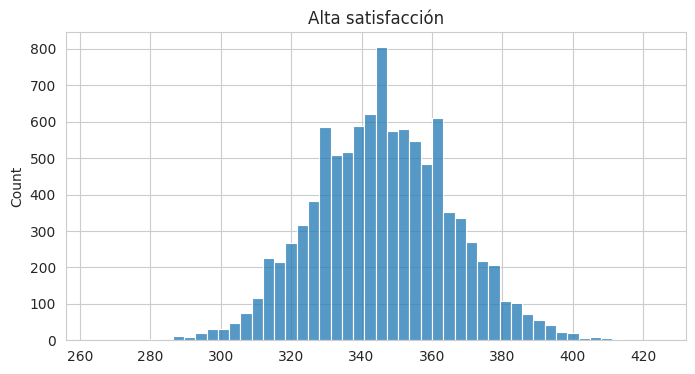

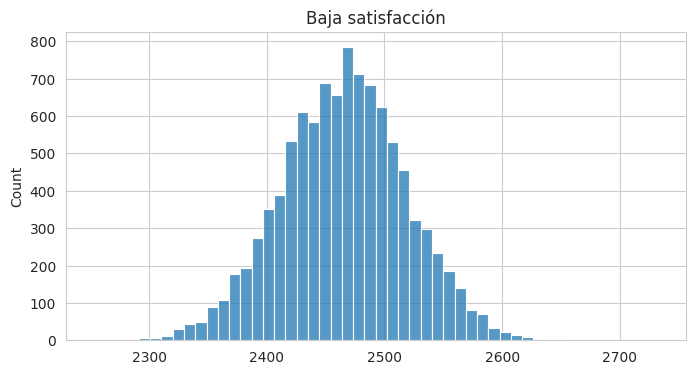

In [45]:
plt.figure(figsize=(8,4))
sns.histplot(simulacion_tardios_alta, bins=50)
plt.title("Alta satisfacción")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(simulacion_tardios_baja, bins=50)
plt.title("Baja satisfacción")
plt.show()

La gráfica muestra una separación total entre los escenarios de alta y baja satisfacción. Esto indica que el número de pedidos tardíos es consistentemente mucho mayor en el escenario de baja satisfacción, sin ambigüedad ni superposición entre resultados posibles.

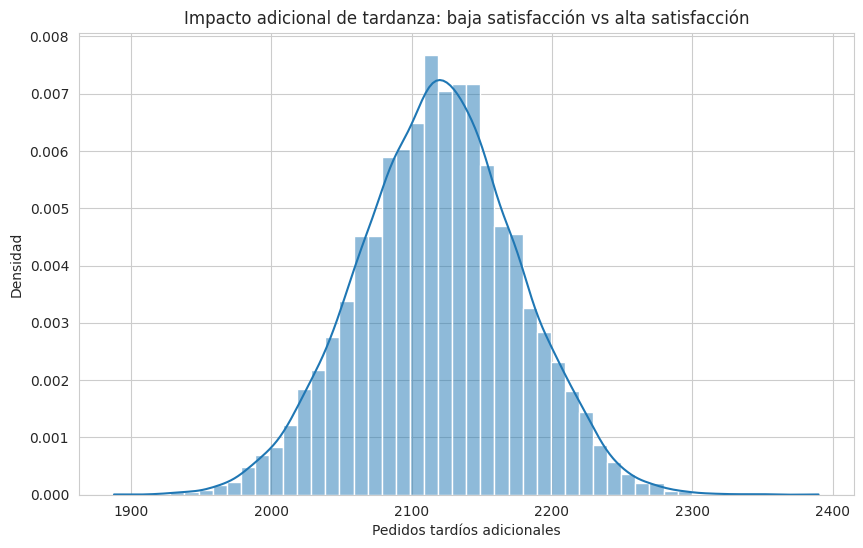

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(impacto_tardanza, bins=50, kde=True, stat="density")
plt.title("Impacto adicional de tardanza: baja satisfacción vs alta satisfacción")
plt.xlabel("Pedidos tardíos adicionales")
plt.ylabel("Densidad")
plt.show()

La gráfica representa la diferencia entre ambos escenarios, mostrando cuántos pedidos tardíos adicionales genera el perfil de baja satisfacción. La distribución es estable y concentrada, lo que indica que el impacto es consistente y predecible.

La simulación Monte Carlo permitió cuantificar el impacto esperado de la tardanza en escenarios futuros bajo distintos perfiles de satisfacción. A partir de las distribuciones posteriores obtenidas mediante inferencia bayesiana, se simularon 10.000 escenarios de pedidos futuros para cada grupo.

Los resultados muestran que, en un lote de 10.000 pedidos, el escenario de alta satisfacción genera en promedio aproximadamente 346 pedidos tardíos, mientras que el escenario de baja satisfacción alcanza cerca de 2.464 pedidos tardíos. Esto implica una diferencia esperada de más de 2.100 pedidos tardíos adicionales en el escenario de baja satisfacción.

Además, la simulación evidencia que esta diferencia es robusta, ya que en el 100% de los escenarios simulados el número de pedidos tardíos es mayor en el grupo de baja satisfacción. Esto confirma que la tardanza no solo está asociada a la insatisfacción del cliente en los datos observados, sino que también representa un riesgo logístico significativo en escenarios futuros.

In [47]:
tabla_final_resultados = pd.DataFrame({
    "componente": [
        "MLE - Normal",
        "MLE - Log-Normal",
        "Bayes - Alta satisfacción",
        "Bayes - Baja satisfacción",
        "Clustering - k=2",
        "Monte Carlo - Alta satisfacción",
        "Monte Carlo - Baja satisfacción",
        "Monte Carlo - Impacto adicional"
    ],
    "resultado_principal": [
        f"AIC={aic_normal:.2f}, BIC={bic_normal:.2f}, mu={mu_normal:.2f}, sigma={sigma_normal:.2f}",
        f"AIC={aic_lognorm:.2f}, BIC={bic_lognorm:.2f}, shape={shape_lognorm:.4f}, scale={scale_lognorm:.2f}",
        f"Media posterior={fila_alta['media_posterior']:.4f}, IC95%=({ic_alta[0]:.4f}, {ic_alta[1]:.4f})",
        f"Media posterior={fila_baja['media_posterior']:.4f}, IC95%=({ic_baja[0]:.4f}, {ic_baja[1]:.4f})",
        "Silhouette=0.4833, Davies-Bouldin=1.3441, Calinski-Harabasz=35639.96",
        f"Promedio={np.mean(simulacion_tardios_alta):.2f}, P5={np.percentile(simulacion_tardios_alta, 5):.2f}, P95={np.percentile(simulacion_tardios_alta, 95):.2f}",
        f"Promedio={np.mean(simulacion_tardios_baja):.2f}, P5={np.percentile(simulacion_tardios_baja, 5):.2f}, P95={np.percentile(simulacion_tardios_baja, 95):.2f}",
        f"Promedio={np.mean(impacto_tardanza):.2f}, P5={np.percentile(impacto_tardanza, 5):.2f}, P95={np.percentile(impacto_tardanza, 95):.2f}"
    ]
})

tabla_final_resultados

,componente,resultado_principal
0,MLE - Normal,"AIC=689021.45, BIC=689040.39, mu=12.43, sigma=..."
1,MLE - Log-Normal,"AIC=637932.12, BIC=637951.06, shape=0.6757, sc..."
2,Bayes - Alta satisfacción,"Media posterior=0.0346, IC95%=(0.0333, 0.0359)"
3,Bayes - Baja satisfacción,"Media posterior=0.2465, IC95%=(0.2406, 0.2525)"
4,Clustering - k=2,"Silhouette=0.4833, Davies-Bouldin=1.3441, Cali..."
5,Monte Carlo - Alta satisfacción,"Promedio=345.92, P5=314.95, P95=378.00"
6,Monte Carlo - Baja satisfacción,"Promedio=2465.26, P5=2377.00, P95=2553.00"
7,Monte Carlo - Impacto adicional,"Promedio=2119.34, P5=2025.00, P95=2213.00"


Se presenta una tabla consolidada con los resultados principales de las cuatro técnicas aplicadas. Esta síntesis reúne la comparación de modelos por máxima verosimilitud, los parámetros e intervalos del análisis bayesiano, las métricas de validación del clustering y los resultados esperados bajo simulación Monte Carlo. Su propósito es integrar en una sola vista los hallazgos cuantitativos más relevantes del proyecto y facilitar su interpretación en términos de negocio.

# Recomendaciones de mejora

In [48]:
# Parámetros base
tasa_actual_tardanza = 0.2465
tasa_objetivo_tardanza = 0.20
volumen_pedidos = 10000
mejora_cumplimiento = 0.15
impacto_adicional_tardanza = 2118.17
proporcion_intervenida = 0.30

# Cálculos
pedidos_evitar_1 = (tasa_actual_tardanza - tasa_objetivo_tardanza) * volumen_pedidos
pedidos_evitar_2 = (tasa_actual_tardanza * volumen_pedidos) * mejora_cumplimiento
pedidos_evitar_3 = impacto_adicional_tardanza * proporcion_intervenida

tabla_impactos = pd.DataFrame({
    "recomendacion": [
        "Reducir tasa de tardanza de 24.65% a 20%",
        "Mejorar cumplimiento en 15% en larga distancia",
        "Intervenir 30% de pedidos de alto riesgo"
    ],
    "formula": [
        "(0.2465 - 0.20) * 10000",
        "(0.2465 * 10000) * 0.15",
        "2118.17 * 0.30"
    ],
    "impacto_estimado_pedidos": [
        round(pedidos_evitar_1),
        round(pedidos_evitar_2),
        round(pedidos_evitar_3)
    ]
})

tabla_impactos

,recomendacion,formula,impacto_estimado_pedidos
0,Reducir tasa de tardanza de 24.65% a 20%,(0.2465 - 0.20) * 10000,465
1,Mejorar cumplimiento en 15% en larga distancia,(0.2465 * 10000) * 0.15,370
2,Intervenir 30% de pedidos de alto riesgo,2118.17 * 0.30,635


1. reducir la tasa de tardanza en el segmento problemático del 24,65% al 20%. En un volumen de 10.000 pedidos, esto permitiría evitar aproximadamente 465 pedidos tardíos, con impacto directo en satisfacción y reducción de reclamos.
2. Ajustar las promesas de entrega en pedidos de larga distancia, especialmente los superiores a 1.000 km. Estos pedidos tardan más de 24 días en promedio y aún así presentan retrasos. Una mejora del 15% en el cumplimiento permitiría evitar cerca de 370 pedidos tardíos por cada 10.000 pedidos en este segmento.
3. Implementar un sistema de alerta temprana basado en probabilidad de tardanza. Clasificando como alto riesgo los pedidos con más del 20% de probabilidad e interviniendo al menos el 30% de ellos, se podrían evitar aproximadamente 600 pedidos tardíos por cada 10.000 pedidos.
